# 🧪 Physics Validation: Schwarzschild Geodesics

This notebook verifies that our `integrator.py` correctly simulates light bending around a black hole (Gravitational Lensing).

In [11]:
import sys
import os

# 1. Configurar backend estable antes de importar pyplot
import matplotlib
matplotlib.use('Agg') # Modo 'Headless' para evitar errores de GUI/RcParams
import matplotlib.pyplot as plt
import numpy as np

# 2. Espejado de arquitectura (Mirroring)
PROJECT_ROOT = os.path.expanduser('~/bh_visualizer')
os.makedirs(os.path.join(PROJECT_ROOT, 'src/engine'), exist_ok=True)
!gcloud storage cp gs://black-hole-visualizer-project-bh-vis-dataproc-config/deploy/src/engine/integrator.py {PROJECT_ROOT}/src/engine/

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.engine import integrator
print(f"✅ Entorno listo en modo estable (Backend: {matplotlib.get_backend()})")


Copying gs://black-hole-visualizer-project-bh-vis-dataproc-config/deploy/src/engine/integrator.py to file:///root/bh_visualizer/src/engine/integrator.py
  Completed files 1/1 | 2.8kiB/2.8kiB                                          
✅ Entorno listo en modo estable (Backend: agg)


In [12]:
# Define a test photon starting at r=20, moving towards the black hole
M = 1.0
RS = 2.0 * M

# State: [t, r, theta, phi, pt, pr, ptheta, pphi]
initial_state = np.array([0.0, 20.0, np.pi/2, 0.0, -1.0, -0.5, 0.0, 4.4])

# Trace the path
path = integrator.trace_photon(initial_state, step_size=0.1, max_steps=2000)

# Convert BL coordinates to quasi-Cartesian for plotting
r = path[:, 1]
phi = path[:, 3]
x = r * np.cos(phi)
y = r * np.sin(phi)

# Plotting
plt.figure(figsize=(10, 10))
plt.plot(x, y, label='Photon Path', color='gold', linewidth=2)

# Draw event horizon
circle = plt.Circle((0, 0), RS, color='black', label='Event Horizon')
plt.gca().add_patch(circle)

# Draw photon sphere (r=3M)
photon_sphere = plt.Circle((0, 0), 3*M, color='red', fill=False, linestyle='--', label='Photon Sphere (3M)')
plt.gca().add_patch(photon_sphere)

plt.xlim(-25, 25)
plt.ylim(-25, 25)
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.title("Light Deflection around a Schwarzschild Black Hole")
plt.legend()
plt.show()

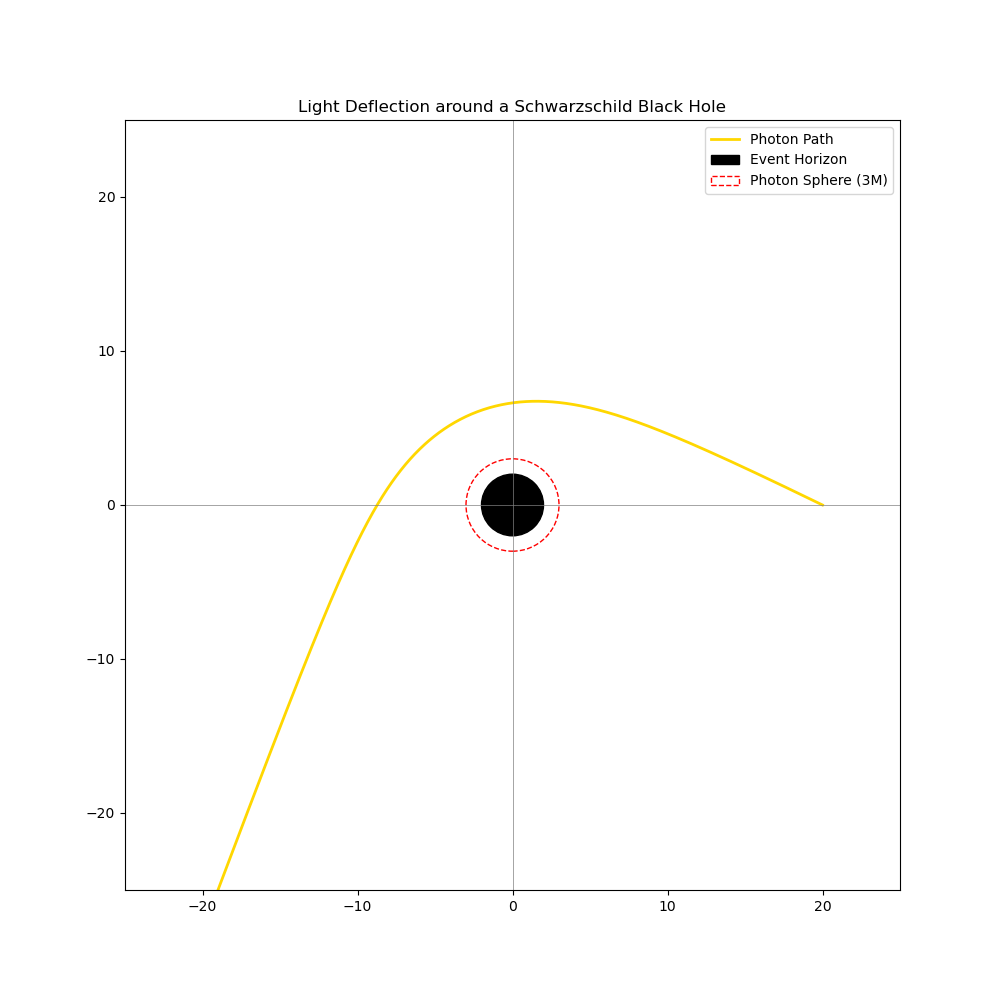

In [13]:
# Al final de tu celda de graficado:
plt.savefig('photon_trace.png') 
from IPython.display import Image, display
display(Image('photon_trace.png')) # Esto fuerza la visualización manual
